# <span style="color:#1f77b4">Project Title: [Insert Your Title Here]</span>

**Names:** Mia Barnett, Angel Li, Helen Wang (2678225)

---

### <span style="color:#1f77b4">Project Overview

This project investigates what race factors influence the results in Formula 1. We will analyze how starting position influences race outcomes and examine the relative importance of drivers and constructors in shaping performance. We aim to better understand whether success in Formula 1 is driven more by race conditions, driver skill, or team advantages.

<font size="4">

**<span style="color:#4f8ff7">Introduction</span>**

</font>

<font size="3">

Formula One (F1) is the highest international class for single-seater racing cars, sanctioned by the Fédération Internationale de l'Automobile (FIA). This is considered the world’s most prestigious motorsport, with races called Grands Prix, meaning “Grand Prize” in French. F1 as we know it today started with the World Championship of Drivers in 1950, and since then, more than a thousand Grands Prix have taken place all over the world. Most races are a minimum of 190 miles and last up to two hours, and a point system based on the placement finishes of each race determines the winners of a single season.

F1 results can be influenced by many race factors, from internal, specific to drivers and teams, to external, such as weather and road conditions. This project investigates which internal factors have the greatest impact on race results. We analyze how starting position influences race outcomes, as drivers are staggered from fastest to slowest, and examine the relative importance of drivers and constructors, which are the individuals racing and the companies that manufacture the cars, in shaping performance. In the end, we observe that success in Formula 1 is ultimately affected by a combination of starting position, driver skill, and team advantages.

</font>

<font size="4">

**<span style="color:#3b6ea8">Data Sets Used</span>**

</font>

<font size="3">

First, we import the necessary Python libraries, pandas and matplotlib.pyplot, and load the datasets used in this project: constructors.csv, drivers.csv, and results.csv. The constructors dataset contains 214 unique F1 constructors since 1950, with each row representing a constructor and including information such as its name and nationality. The drivers dataset includes 855 unique Formula 1 drivers, where each row represents an individual driver and contains details such as their name, nationality, driver code, and racing number. Finally, the results dataset contains 25,665 observations, with each row representing a driver’s performance in a specific race, including variables such as grid position, finishing position, and race time. Together, these datasets allow us to analyze race outcomes in relation to both driver and constructor characteristics, as well as performance metrics across over one thousand Formula 1 races.

</font>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df_results = pd.read_csv("data/results.csv")
df_drivers = pd.read_csv("data/drivers.csv")
df_constructors = pd.read_csv("data/constructors.csv")

<font size="4">

**<span style="color:#3b6ea8">Merging Procedures</span>**

</font>

<font size="3">
We constructed our main dataset by merging three tables: results, drivers, and constructors. First, we selected relevant variables from each dataset that relate to race outcomes, driver identity, and constructor information. Before merging, we renamed overlapping columns such as “nationality” and “constructor name” to avoid ambiguity in the final dataframe.

Then, we used the results table as the main dataframe and perform a left merge with the drivers table using `driverId`, followed by a second merge with the constructors table using `constructorId`. The final merged dataset, stored as `df`, contains all relevant information needed for our analysis and is used in all subsequent computations and models.
</font>

In [2]:
#check columns
results_col = df_results.columns
drivers_col = df_drivers.columns
constructors_col = df_constructors.columns
print("Results Columns: ", results_col)
print()
print("Drivers Columns: ", drivers_col)
print()
print("Constructors Columns: ", constructors_col)


Results Columns:  Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'position', 'positionText', 'positionOrder', 'points', 'laps', 'time',
       'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
       'fastestLapSpeed', 'statusId'],
      dtype='object')

Drivers Columns:  Index(['driverId', 'driverRef', 'number', 'code', 'forename', 'surname', 'dob',
       'nationality', 'url'],
      dtype='object')

Constructors Columns:  Index(['constructorId', 'constructorRef', 'name', 'nationality', 'url'], dtype='object')


In [3]:
#select columns for each dataset
results_sub = df_results[["raceId","driverId", "constructorId", "grid", "positionOrder", "points", "laps"]]
drivers_sub = df_drivers[["driverId", "forename", "surname", "nationality"]]
constructors_sub = df_constructors[["constructorId", "name", "nationality"]]

#rename overlapping columns
drivers_sub = drivers_sub.rename(columns={"nationality": "driver_nationality"})
constructors_sub = constructors_sub.rename(columns={"name": "constructor_name", "nationality": "constructor_nationality"})


#merging
df = pd.merge(left = results_sub, right = drivers_sub, on="driverId", how="left")
df = pd.merge(left = df, right = constructors_sub, on="constructorId", how="left")

# fixing name:
df['driver'] = df['forename'] + " " + df['surname']
df['constructor'] = df['constructor_name']

display(df)

,raceId,driverId,constructorId,grid,positionOrder,points,laps,forename,surname,driver_nationality,constructor_name,constructor_nationality,driver,constructor
0,18,1,1,1,1,10.0,58,Lewis,Hamilton,British,McLaren,British,Lewis Hamilton,McLaren
1,18,2,2,5,2,8.0,58,Nick,Heidfeld,German,BMW Sauber,German,Nick Heidfeld,BMW Sauber
2,18,3,3,7,3,6.0,58,Nico,Rosberg,German,Williams,British,Nico Rosberg,Williams
3,18,4,4,11,4,5.0,58,Fernando,Alonso,Spanish,Renault,French,Fernando Alonso,Renault
4,18,5,1,3,5,4.0,58,Heikki,Kovalainen,Finnish,McLaren,British,Heikki Kovalainen,McLaren
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25655,1086,825,210,13,16,0.0,69,Kevin,Magnussen,Danish,Haas F1 Team,American,Kevin Magnussen,Haas F1 Team
25656,1086,848,3,17,17,0.0,69,Alexander,Albon,Thai,Williams,British,Alexander Albon,Williams
25657,1086,849,3,19,18,0.0,69,Nicholas,Latifi,Canadian,Williams,British,Nicholas Latifi,Williams
25658,1086,852,213,16,19,0.0,68,Yuki,Tsunoda,Japanese,AlphaTauri,Italian,Yuki Tsunoda,AlphaTauri


<font size="4">

**<span style="color:#3b6ea8">Cleaning Procedures</span>**

</font>

<font size="3">

While cleaning, we examined the key variables used in our analysis, including `grid`, `positionOrder`, `points`, and `laps`. We found that these variables are already in numeric format and do not contain any missing values. However, we identified some invalid observations, such as rows where `grid` and `laps` equal 0, which are not meaningful in the context of Formula 1 race results. We removed these observations to ensure the dataset accurately reflects valid race performances and to improve the reliability of our analysis.
</font>

In [4]:
#define a function to check for missing values/ invalid data
def check_data_quality(df):
    print("Shape:", df.shape)
    
    print("Missing values:")
    print(df[["grid", "positionOrder", "points", "laps"]].isna().sum())
    
    print("Invalid values:")
    print("grid <= 0:", (df["grid"] <= 0).sum())
    print("positionOrder <= 0:", (df["positionOrder"] <= 0).sum())
    print("laps <= 0:", (df["laps"] <= 0).sum())
    
    print("Summary statistics:")
    print(df[["grid", "positionOrder", "points", "laps"]].describe().round(2))

print("Before cleaning:")
check_data_quality(df)

Before cleaning:
Shape: (25660, 14)
Missing values:
grid             0
positionOrder    0
points           0
laps             0
dtype: int64
Invalid values:
grid <= 0: 1604
positionOrder <= 0: 0
laps <= 0: 2502
Summary statistics:
           grid  positionOrder    points      laps
count  25660.00       25660.00  25660.00  25660.00
mean      11.19          12.89      1.85     45.94
std        7.25           7.72      4.13     29.87
min        0.00           1.00      0.00      0.00
25%        5.00           6.00      0.00     22.00
50%       11.00          12.00      0.00     52.00
75%       17.00          18.00      2.00     66.00
max       34.00          39.00     50.00    200.00


In [5]:
#remove invalid data
df = df.query("grid > 0 and laps > 0")
display(df)

,raceId,driverId,constructorId,grid,positionOrder,points,laps,forename,surname,driver_nationality,constructor_name,constructor_nationality,driver,constructor
0,18,1,1,1,1,10.0,58,Lewis,Hamilton,British,McLaren,British,Lewis Hamilton,McLaren
1,18,2,2,5,2,8.0,58,Nick,Heidfeld,German,BMW Sauber,German,Nick Heidfeld,BMW Sauber
2,18,3,3,7,3,6.0,58,Nico,Rosberg,German,Williams,British,Nico Rosberg,Williams
3,18,4,4,11,4,5.0,58,Fernando,Alonso,Spanish,Renault,French,Fernando Alonso,Renault
4,18,5,1,3,5,4.0,58,Heikki,Kovalainen,Finnish,McLaren,British,Heikki Kovalainen,McLaren
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25655,1086,825,210,13,16,0.0,69,Kevin,Magnussen,Danish,Haas F1 Team,American,Kevin Magnussen,Haas F1 Team
25656,1086,848,3,17,17,0.0,69,Alexander,Albon,Thai,Williams,British,Alexander Albon,Williams
25657,1086,849,3,19,18,0.0,69,Nicholas,Latifi,Canadian,Williams,British,Nicholas Latifi,Williams
25658,1086,852,213,16,19,0.0,68,Yuki,Tsunoda,Japanese,AlphaTauri,Italian,Yuki Tsunoda,AlphaTauri


Checking after data-preprocessing:

In [6]:
print("After cleaning:")
check_data_quality(df)

After cleaning:
Shape: (23118, 14)
Missing values:
grid             0
positionOrder    0
points           0
laps             0
dtype: int64
Invalid values:
grid <= 0: 0
positionOrder <= 0: 0
laps <= 0: 0
Summary statistics:
           grid  positionOrder    points      laps
count  23118.00       23118.00  23118.00  23118.00
mean      11.86          11.52      2.06     50.90
std        6.87           6.65      4.30     27.14
min        1.00           1.00      0.00      1.00
25%        6.00           6.00      0.00     34.00
50%       12.00          11.00      0.00     54.00
75%       17.00          17.00      2.00     68.00
max       34.00          33.00     50.00    200.00


<font size="4">

**<span style="color:#3b6ea8">Descriptive Statistics</span>**

</font>

<font size="3"> 

To better understand the structure of our merged dataset, we compute descriptive statistics for the key variables used in our analysis: `grid`, `positionOrder`, `points`, and `laps`. These variables capture important aspects of race performance, including starting position, finishing position, points earned, and race completion.

We chose to focus on the summary statistics of mean, standard deviation, min and max, which allow us to better understand typical race conditions as well as the spread of outcomes across drivers and races. We focus only on these selected variables in order to maintain a clear and relevant analysis centered on race performance rather than extraneous features.
</font>

In [7]:
desc_stats = df[["grid", "positionOrder", "points", "laps"]].describe().loc[["mean", "std", "min", "max"]].round(2)
display(desc_stats)


,grid,positionOrder,points,laps
mean,11.86,11.52,2.06,50.90
std,6.87,6.65,4.30,27.14
min,1.00,1.00,0.00,1.00
max,34.00,33.00,50.00,200.00


<font size="5">

**<span style="color:#4f8ff7">Plotting Relationships With Our Data Set</span>**

</font>

<font size="3">

Below are a variety of graphical plots examining different relationships among variables in the data set.

</font>

<font size="4">

**<span style="color:#3b6ea8">Starting Position (Grid) vs. Finishing Position</span>**

</font>

<font size="3">

We chose to begin by analyzing whether starting position has an impact on finishing position. 

Since drivers are arranged on the starting grid based on qualifying performance, this comparison allows us to evaluate how strongly qualifying results predict final race outcomes. If drivers closer to the front of the grid are the ones that end up finishing faster, it becomes apparent that the starting position (determined by qualifying results) has an impact on finishing. Here, we plot drivers' grid positions against their finishing positions in races.

</font>

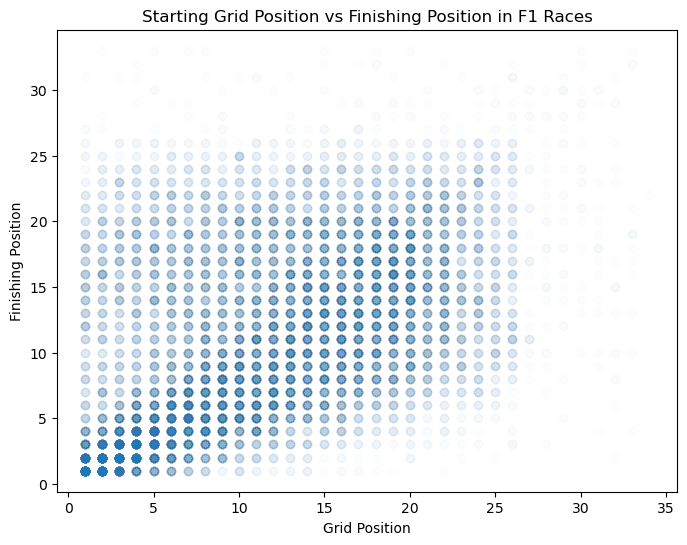

In [8]:
plot_df = df[(df['grid'] > 0) & (df['positionOrder'] > 0)]

plt.figure(figsize=(8,6)) # makes the graph bigger --> more readable
plt.scatter(plot_df['grid'], plot_df['positionOrder'], alpha=0.01) # low alpha makes the trend easier to see

plt.title('Starting Grid Position vs Finishing Position in F1 Races')
plt.xlabel('Grid Position')
plt.ylabel('Finishing Position')

plt.show()

The scatter plot of grid position versus finishing position shows a clear positive relationship.
Drivers starting closer to the front of the grid tend to finish in higher positions, while those starting further back are more likely to finish lower in the standings. 

The pattern is not perfectly linear, indicating that there are many other factors like accidents and new strategic choices that can influence outcomes.

However, the overall trend suggests that starting position is a strong predictor of race results: a driver with a top grid position is more likely to have a top finishing position, while a driver with a lower grid position may not do as well in the final race.

This finding highlights the importance of qualifying performance in Formula 1. While races allow for constant position changes, gaining an advantage at the start (a grid position closer to the front) significantly increases the likelihood of a strong finishing result.

<font size="4">

**<span style="color:#3b6ea8">Top Drivers (individuals)</span>**

</font>

<font size="3">

To determine whether individual driver skill plays a major role in race outcomes, we computed the average finishing position for each driver and identified the top performers in the dataset. This allows us to evaluate how consistently drivers perform across races and whether skill alone explains success in Formula 1. 

</font>

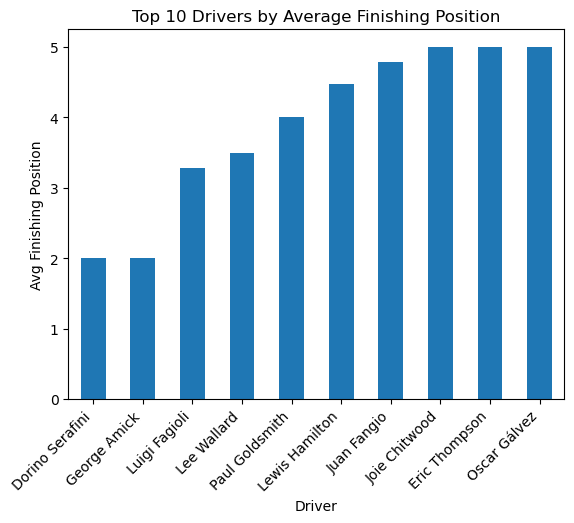

In [9]:
# Found by their Average Finishing Position
driver_perf = df[df['positionOrder'] > 0].groupby('driver')['positionOrder'].mean()
#display(driver_perf)

top_drivers = driver_perf.sort_values().head(10)
#print(top_drivers)

top_drivers.plot(kind='bar')

plt.title('Top 10 Drivers by Average Finishing Position')
plt.xlabel('Driver')
plt.ylabel('Avg Finishing Position')

plt.xticks(rotation=45, ha='right') # looked up how to do this to make the driver's names more readable and on a 45 degree angle
plt.show()

The bar chart of the top 10 drivers by average finishing position shows that a small group of drivers consistently achieves strong results. All of these drivers maintain strong average finishing positions (generally top 5), indicating a high level of performance stability over time. 

However, the differences between these top drivers are relatively small, suggesting that while individual skill is important, it is not the sole determinant of success. Other factors, such as starting position and team performance, likely play a more significant role in shaping outcomes. In particular, starting position provides an early advantage, while car quality and team strategy can heavily influence a driver’s ability to maintain or improve their position during a race. 

Overall, this result highlights that top drivers tend to perform consistently well, but their success cannot be explained by skill alone. Instead, Formula 1 performance appears to be driven by a combination of driver ability, starting position, and constructor advantages.

<font size="4">

**<span style="color:#3b6ea8">Top Teams (Constructors)</span>**

</font>

<font size="3">

We also decided to look at if a driver's team plays a role their Formula 1 success.

In this context, we know that constructors represent the teams that design and build the cars. This means that the racer’s performance reflects engineering and building quality, budget, and strategic capability. 

To investigate the impact of the constructor team on success, we calculated the average points earned per race by each constructor. Then, we displayed the top constructors' average points per race in a bar graph.

</font>

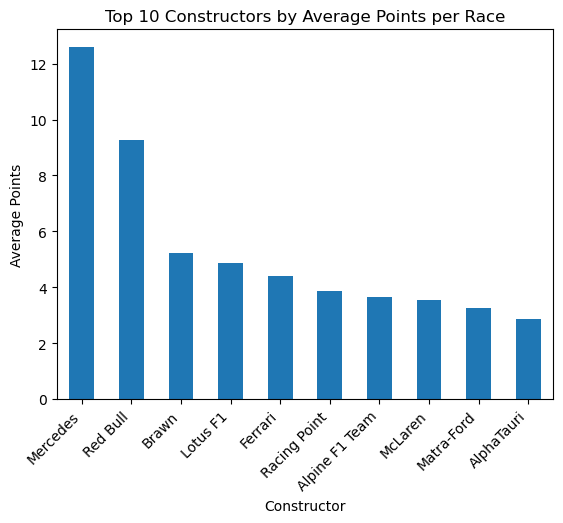

In [10]:
# Found by their Average points per race

constructor_perf = df.groupby('constructor')['points'].mean()

top_constructors = constructor_perf.sort_values(ascending=False).head(10)

top_constructors.plot(kind='bar')

plt.title('Top 10 Constructors by Average Points per Race')
plt.xlabel('Constructor')
plt.ylabel('Average Points')

plt.xticks(rotation=45, ha='right') # looked up how to do this to make the driver's names more readable and on a 45 degree angle
plt.show()

The bar chart of the top constructors by average points per race showed surprising results, a clear performance difference between teams. The top constructor, Mercedes, had 3 more average points per race than the second top constructor, Red Bull. This, relative to the data, is a large difference. 

These results prove that a small number of constructors consistently outperform others, earning significantly higher average points. This further indicates that certain teams have technical and strategic advantages that have grown and continued to dominate overtime. 

This suggests that constructor performance plays a major role in determining race outcomes. Unlike individual drivers, where differences are more gradual, constructors show more distinct separation in performance levels, reinforcing the importance of team resources and car quality in Formula 1 success.

<font size="4">

**<span style="color:#3b6ea8">Starting Position (Grid) vs. Points per Race </span>**

</font>

<font size="3">

After determining that those in a starting position closer to the front tend to end up in a finishing position closer to the front, we decided to further explore the importance of grid position. 

To do so, we analyzed the relationship between starting position and total points earned in a race. Points are awarded based on finishing position, making this a direct measure of race success. Each point represents the race result of an individual driver, where its x-value reflects the driver's starting position, and the y-value shows how many points they earned.

</font>

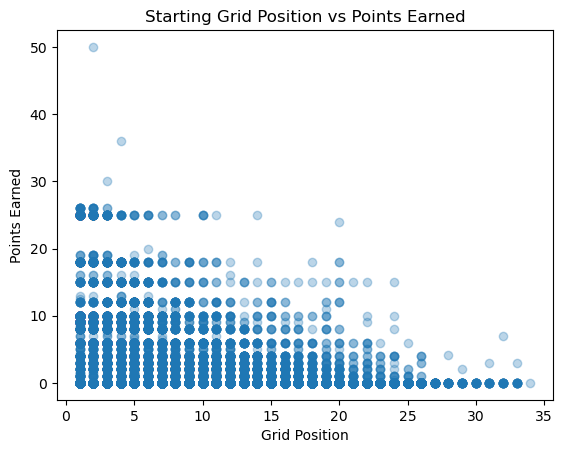

: 

In [ ]:
filtered_df = df[df['grid'] > 0]

plt.scatter(filtered_df['grid'], filtered_df['points'], alpha=0.3)

plt.title('Starting Grid Position vs Points Earned')
plt.xlabel('Grid Position')
plt.ylabel('Points Earned')

plt.show()

The scatter plot shows that drivers starting closer to the front tend to earn more points on average, while those starting further back generally earn fewer points. 

However, there is noticeable variation in the data, indicating that drivers can still recover positions and score points even from lower grid positions. While we do see a general pattern, the data isn’t as clear, indicating that starting grid position isn’t as strong of a predictor of success as we originally may have thought. 

This result reinforces earlier findings, that while starting position influences race outcomes, it is not absolute. Strategy, overtaking ability, constructor, car quality, race conditions, and more can still significantly impact final performance.

<font size="4">

**<span style="color:#3b6ea8">Discussion </span>**

</font>

<font size="3">

This analysis explored the relative importance of starting position, driver performance, and constructor influence on F1 race outcomes. Our results show that starting grid position is a strong predictor of finishing position, but does not serve as a perfect indicator of race results. Additionally, while top drivers consistently perform well, the differences between them are relatively small compared to the variation we see across different constructors. This suggests that broader team-related factors, such as car quality and engineering, have a greater impact on driver success than their skill alone. Finally, the relationship between starting position and the points a driver earns further reinforces the importance of a strong qualifying score, while also showing that a driver with a lower grid position is still able to perform well in the final race. Overall, Formula 1 success is driven by a combination of starting advantage, team strength, and driver ability, rather than any one factor by itself.

</font>